# Build the Data Collection Pipeline

In [107]:
import pandas as pd
import requests
import json
import numpy as np

response = requests.get('https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100')

In [108]:
data = response.json()
df = pd.DataFrame(data['items'])

In [109]:
data=response.json()
df=pd.DataFrame(data['items'])

In [110]:
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76064,3039,197059,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34276,2377,164253,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21977,13,89519,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15266,52,82543,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15612,26,74069,master,1.0


In [111]:
df.tail()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
95,126573668,MDEwOlJlcG9zaXRvcnkxMjY1NzM2Njg=,Machine-learning-learning-notes,Vay-keen/Machine-learning-learning-notes,False,"{'login': 'Vay-keen', 'id': 9793783, 'node_id'...",https://github.com/Vay-keen/Machine-learning-l...,周志华《机器学习》又称西瓜书是一本较为全面的书籍，书中详细介绍了机器学习领域不同类型的算法(...,False,https://api.github.com/repos/Vay-keen/Machine-...,...,False,True,all,[],public,1878,28,7762,master,1.0
96,290234921,MDEwOlJlcG9zaXRvcnkyOTAyMzQ5MjE=,awesome-youtubers,JoseDeFreitas/awesome-youtubers,False,"{'login': 'JoseDeFreitas', 'id': 37962411, 'no...",https://github.com/JoseDeFreitas/awesome-youtu...,An awesome list of awesome YouTubers that teac...,False,https://api.github.com/repos/JoseDeFreitas/awe...,...,False,True,all,"[awesome, awesome-list, list, youtube, youtubers]",public,493,2,7697,main,1.0
97,123568881,MDEwOlJlcG9zaXRvcnkxMjM1Njg4ODE=,Learn_Machine_Learning_in_3_Months,llSourcell/Learn_Machine_Learning_in_3_Months,False,"{'login': 'llSourcell', 'id': 1279609, 'node_i...",https://github.com/llSourcell/Learn_Machine_Le...,"This is the code for ""Learn Machine Learning i...",False,https://api.github.com/repos/llSourcell/Learn_...,...,False,True,all,[],public,2310,19,7606,master,1.0
98,17371412,MDEwOlJlcG9zaXRvcnkxNzM3MTQxMg==,h2o-3,h2oai/h2o-3,False,"{'login': 'h2oai', 'id': 1402695, 'node_id': '...",https://github.com/h2oai/h2o-3,"H2O is an Open Source, Distributed, Fast & Sca...",False,https://api.github.com/repos/h2oai/h2o-3,...,False,True,all,"[automl, big-data, data-science, deep-learning...",public,2026,2883,7492,master,1.0
99,184701688,MDEwOlJlcG9zaXRvcnkxODQ3MDE2ODg=,industry-machine-learning,firmai/industry-machine-learning,False,"{'login': 'firmai', 'id': 26666267, 'node_id':...",https://github.com/firmai/industry-machine-lea...,A curated list of applied machine learning and...,False,https://api.github.com/repos/firmai/industry-m...,...,False,True,all,"[data-science, datascience, example, firmai, j...",public,1249,3,7485,master,1.0


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [113]:
df.shape

(100, 82)

In [114]:
df.dtypes

,0
id,int64
node_id,object
name,object
full_name,object
private,bool
...,...
forks,int64
open_issues,int64
watchers,int64
default_branch,object


In [115]:
df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [116]:
required_columns = ["name","owner","language","stargazers_count","forks_count","watchers_count","open_issues_count","created_at","updated_at","license"]

df = df[required_columns]

In [117]:
df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [118]:
df["owner"] = df["owner"].apply(lambda x: x.get("login") if isinstance(x, dict) else None)
df["license"] = df["license"].apply(lambda x: x.get("spdx_id") if isinstance(x, dict) else None)

In [119]:
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("No License")

In [120]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [121]:
df = df.rename(columns={"stargazers_count": "stars","forks_count": "forks","watchers_count": "watchers","open_issues_count": "open_issues","created_at": "created_date","updated_at": "updated_date"})

In [122]:
df.to_csv("github_projects.csv", index=False)

In [123]:
import pandas as pd

github_projects = pd.read_csv("github_projects.csv")

print(github_projects.head())
print(github_projects.shape)
print(github_projects.isnull().sum())

                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197059  76064   
1              transformers     huggingface            Python  164253  34276   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89519  21977   
3                    funNLP  fighting41love            Python   82543  15266   
4  awesome-machine-learning    josephmisiti            Python   74069  15612   

   watchers  open_issues               created_date  \
0    197059         3039  2015-11-07 01:19:20+00:00   
1    164253         2377  2018-10-29 13:56:00+00:00   
2     89519           13  2021-03-03 01:34:05+00:00   
3     82543           52  2018-08-21 11:20:39+00:00   
4     74069           26  2014-07-15 19:11:19+00:00   

                updated_date      license  
0  2026-08-19 11:10:51+00:00   Apache-2.0  
1  2026-08-19 11:47:07+00:00   Apache-2.0  
2  2026-08-19 11:45:45+00:00          MIT  
3  2026-08-1

# Store and Analyze the Data

In [124]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [125]:
!pip install ipython-sql==0.5.0 prettytable==3.9.0

In [126]:
%load_ext sql
%config SqlMagic.style = 'PLAIN_COLUMNS'

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [127]:
df = pd.read_csv("/content/github_projects.csv")


In [128]:
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197059,76064,197059,3039,2015-11-07 01:19:20+00:00,2026-08-19 11:10:51+00:00,Apache-2.0
1,transformers,huggingface,Python,164253,34276,164253,2377,2018-10-29 13:56:00+00:00,2026-08-19 11:47:07+00:00,Apache-2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89519,21977,89519,13,2021-03-03 01:34:05+00:00,2026-08-19 11:45:45+00:00,MIT
3,funNLP,fighting41love,Python,82543,15266,82543,52,2018-08-21 11:20:39+00:00,2026-08-19 11:49:30+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74069,15612,74069,26,2014-07-15 19:11:19+00:00,2026-08-19 10:47:52+00:00,NOASSERTION


In [129]:
%load_ext sql
%sql sqlite:////content/github_projects.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [130]:
%%sql
SELECT *
FROM Repositories
WHERE stars > 10000;

 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT *
FROM Repositories
WHERE stars > 10000;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [131]:
%%sql
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%'


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT *
FROM Repositories
WHERE name LIKE '%Machine%']
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [132]:
%%sql
SELECT *
FROM Repositories
WHERE stars > 10000
AND forks > 1000;


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT *
FROM Repositories
WHERE stars > 10000
AND forks > 1000;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [133]:
%%sql
SELECT *
FROM Repositories
WHERE language = 'Python'
OR language = 'JavaScript';


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT *
FROM Repositories
WHERE language = 'Python'
OR language = 'JavaScript';]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [134]:
%%sql
SELECT *
FROM Repositories
WHERE NOT language = 'Unknown';


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT *
FROM Repositories
WHERE NOT language = 'Unknown';]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [135]:
%%sql
SELECT *
FROM Repositories
ORDER BY stars DESC;


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT *
FROM Repositories
ORDER BY stars DESC;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [136]:
%%sql
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [137]:
%%sql
SELECT COUNT(*) AS total_repositories
FROM Repositories;


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT COUNT(*) AS total_repositories
FROM Repositories;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [138]:
%%sql
SELECT AVG(stars) AS average_stars
FROM Repositories;


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT AVG(stars) AS average_stars
FROM Repositories;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [139]:
%%sql
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;


 * sqlite:////content/github_projects.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [143]:
top10 = df.sort_values("stars",ascending=False).head(10)

In [142]:
df.columns

Index(['name', 'owner', 'language', 'stars', 'forks', 'watchers',
       'open_issues', 'created_date', 'updated_date', 'license'],
      dtype='object')

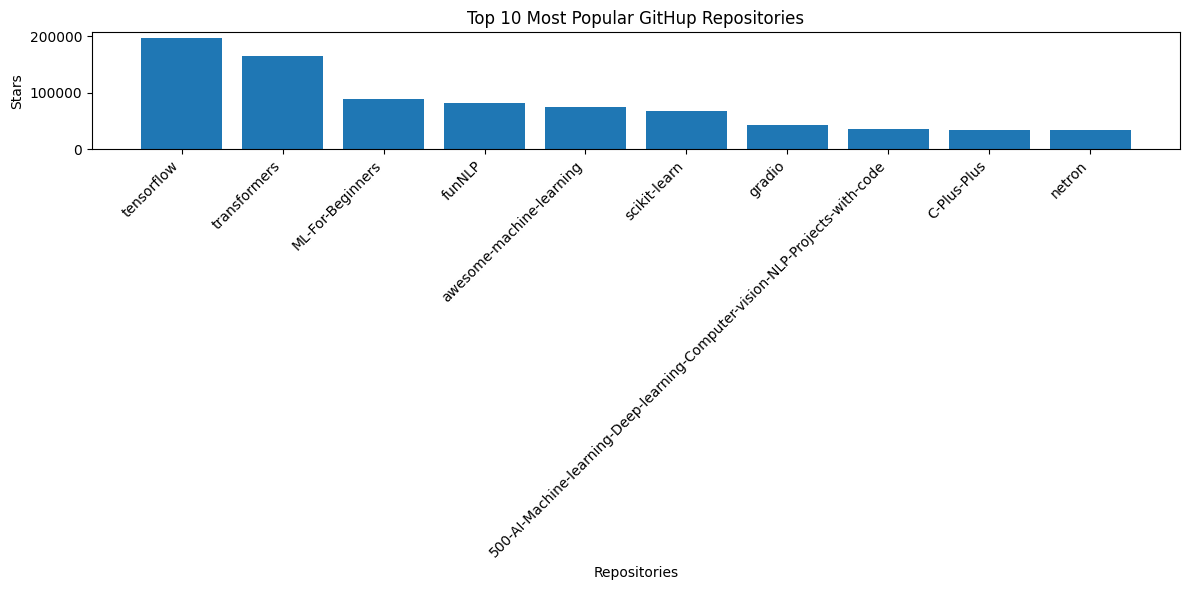

In [145]:
plt.figure(figsize=(12, 6))

plt.bar(top10["name"], top10["stars"])

plt.title("Top 10 Most Popular GitHup Repositories")
plt.xlabel("Repositories")
plt.ylabel("Stars")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

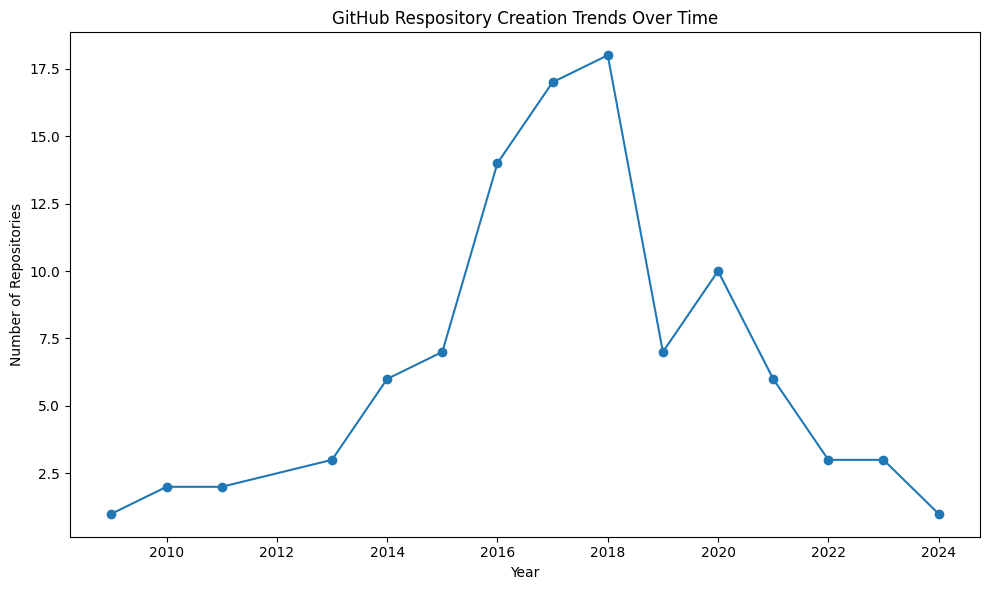

In [146]:
df["created_date"] = pd.to_datetime(df["created_date"])

creation_trends = (
    df.groupby(df["created_date"].dt.year)
    .size()
    .reset_index(name="respository_count")
)

plt.figure(figsize=(10, 6))

plt.plot(
    creation_trends["created_date"],
    creation_trends["respository_count"],
    marker="o"
)

plt.title("GitHub Respository Creation Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")

plt.tight_layout()
plt.show

# Trends in the data

*tensorflow was the most owner that has stars

*the highest year in the Respository Creation was 2018

#Business questions

.the most popular programming language was python as it used 53 times

.the greatest number of stars in the programming language was python

.the most popular license was MIT license 27

# DATA ETHICS

##Why is it important to verify data collected from public APIs???




* Accuracy : ensure that the data is collected is accurate and reflects the real world truth after collection
*  reliability : ensure that the data is trustworthy , and suitable for making decisions



##Why should data analysts document the source of their data???



*   Increases transparency :When you document all of your datasets, everyone within the business has a window into the data available to them:



##How can missing or inaccurate data affect data analysis and decision-making???




* Inaccurate Data: Leads to wrong conclusions and undermines trust in analytics

*   Duplicate Data: lead to change the Skews trend analysis
* Incomplete Data: Results in gaps that can halt integration processes





GitHub repo
https://github.com/basmalaemad92010-source/GitHub_Machine_Learning_Project